Sentiment Analysis

Step 0 - read data and nltk basics

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

import nltk

In [2]:
df = pd.read_csv('/kaggle/input/reviwes/Reviews.csv')

In [3]:
df.head()

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


In [4]:
print(df.shape)

(568454, 10)


In [5]:
 # Aa datasaet is too large we make it less
df = df.head(1000)
print(df.shape)

(1000, 10)


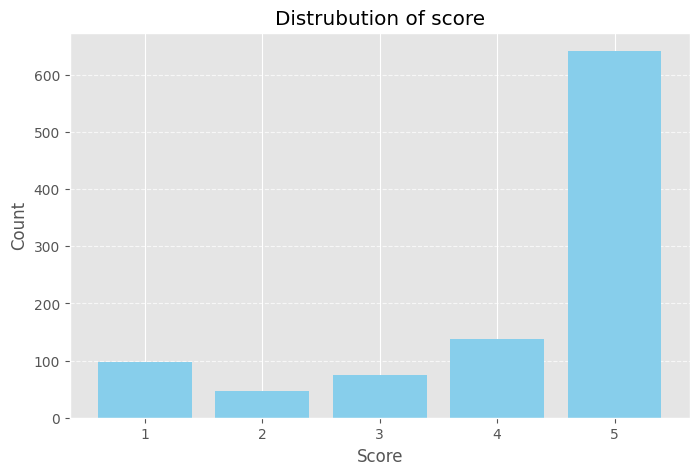

In [6]:
# Count occurrences of each score
score_counts = df['Score'].value_counts().sort_index()

# plot the bar chart
plt.figure(figsize = (8,5))
plt.bar(score_counts.index,score_counts.values,color = "skyblue")
plt.xlabel("Score")
plt.ylabel("Count")
plt.title("Distrubution of score")
plt.xticks(score_counts.index) #ensure all score are shown as x-axis labels
plt.grid(axis="y",linestyle = "--",alpha =0.7)
plt.show()


# **Basic NLTK**

Step1 - VADER sentiment scoring
we will use the NLTK's SentimentIntensityAnalyzer to get the negative/neutral/positive scores of test

This uses a bag of words approach:

    1.Stop words are removes
    2.each word is scored and combined to a total score

VADER (Valence Aware Dictionary and sEntiment Reasoner) is a sentiment analysis tool specifically designed to recognize sentiment in text, especially in social media and product reviews. It is part of the NLTK (Natural Language Toolkit) and is known for its ability to handle informal language, slang, and even emojis.

In [7]:
from nltk.sentiment import SentimentIntensityAnalyzer
from tqdm.notebook import tqdm  # Importing tqdm for displaying progress bars in Jupyter notebooks

# Initialize the SentimentIntensityAnalyzer
sa = SentimentIntensityAnalyzer()

/usr/local/lib/python3.10/dist-packages/nltk/twitter/__init__.py:20: UserWarning: The twython library has not been installed. Some functionality from the twitter package will not be available.
  warnings.warn("The twython library has not been installed. "


In [8]:
#Example
sa.polarity_scores('I am so happy')

#compund represent how ngative ir positive the text is

{'neg': 0.0, 'neu': 0.334, 'pos': 0.666, 'compound': 0.6115}

In [9]:
sa.polarity_scores('This is the worst product ever')

{'neg': 0.451, 'neu': 0.549, 'pos': 0.0, 'compound': -0.6249}

In [10]:
# Enable tqdm progress bar for Pandas operations
tqdm.pandas()
# Apply Sentiment Analysis on the "Text" column using VADER and store results in new columns
df[["neg","neu","pos","compound"]] =df["Text"].progress_apply(
    lambda x: pd.Series(sa.polarity_scores(str(x)))
)

# Print the first five rows to check sentiment scores
print(df[["neg","neu","pos","compound"]].head())

  0%|          | 0/1000 [00:00<?, ?it/s]

     neg    neu    pos  compound
0  0.000  0.695  0.305    0.9441
1  0.079  0.853  0.068   -0.1027
2  0.091  0.754  0.155    0.8265
3  0.000  1.000  0.000    0.0000
4  0.000  0.552  0.448    0.9468


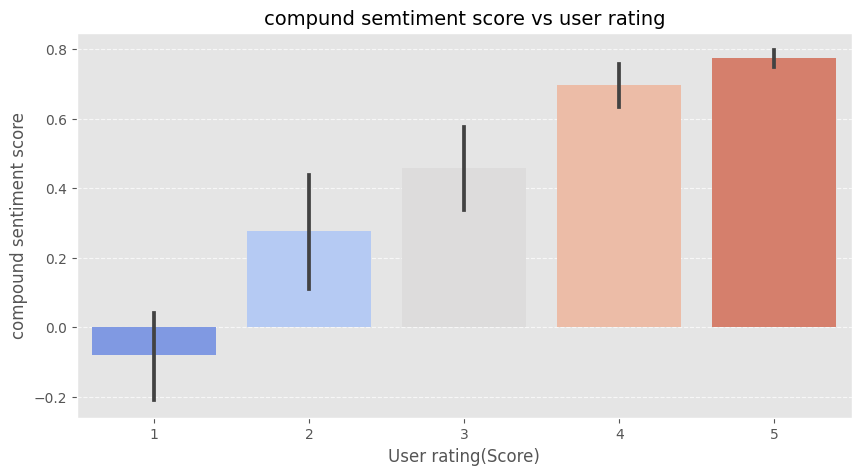

In [11]:
# Set figure size
plt.figure(figsize = (10,5))

# Create a bar plot showing individual compound sentiment scores for each rating
sns.barplot(x=df["Score"],y=df["compound"],palette = "coolwarm")

# Labels and title
plt.xlabel("User rating(Score)",fontsize = 12)
plt.ylabel("compound sentiment score",fontsize = 12)
plt.title("compund semtiment score vs user rating",fontsize = 14)
plt.grid(axis="y",linestyle = "--",alpha = 0.7)
plt.show()

**#  What This Plot Shows**> 

X-axis → User Ratings (1 to 5 stars)
Y-axis → Corresponding compound sentiment score

Expected Trend:

Higher ratings (like 5 stars) should have higher compound scores (~0.8 to 1.0)

Lower ratings (like 1 star) should have negative compound scores (~-1.0 to -0.5)